# Retreino dos modelos nas três configurações de preditores

Quanto o desempenho muda quando a codificação dos 24 campos clínicos e das categóricas é corrigida, e quanto se perde ao restringir os preditores ao que está disponível na notificação.
Treina os cinco algoritmos do estudo - Logistic Regression, Decision Tree, Random Forest, XGBoost e LightGBM - nas versões base e otimizada, em cada uma das três configurações definidas em `utils/configuracoes.py`, com o pré-processamento de cada família vindo de `utils/preprocessamento.py`.
Avalia no teste de 2024 com intervalos de confiança por bootstrap, e confere que a configuração antiga reproduz a análise publicada.
Sem calibração, sem F-beta e sem ajuste de limiar: o limiar de decisão fica fixo em 0,5, e a validação de 2025 fica reservada.

## Etapas
1. Carregar as três bases e montar a partição temporal de `utils/split_data.py`.
2. Listar o pré-processamento de cada família e conferir quantas colunas ele entrega no treino.
3. Auditar a codificação preditor a preditor, com o tipo da variável e a codificação que ela recebe.
4. Definir o bootstrap por pesos, que permite usar as mesmas reamostragens em todos os modelos.
5. Definir os cinco algoritmos e as grades de hiperparâmetros de `notebooks/01_models`.
6. Treinar as 30 combinações de algoritmo, versão e configuração, gravando modelo, métricas e predições.
7. Rodar o bootstrap de 2.000 reamostragens do teste de 2024.
8. Montar as tabelas de desempenho completo e de comparação entre configurações.
9. Conferir a coorte e as matrizes contra `data/features/baseline/`, e as predições contra `output/metricas/`.
10. Contar os eventos por preditor nas duas contagens, entrada e matriz de desenho.
11. Gravar as figuras de floresta, o painel de métricas e as curvas precisão-revocação.

## Entradas
- `data/processed/dengue_treated_antiga.parquet`
- `data/processed/dengue_treated_corrigida.parquet`
- `data/processed/dengue_treated_notificacao.parquet`
- `data/features/baseline/` (matrizes e `config.json` da análise publicada)
- `output/metricas/` (predições publicadas, para conferência)

## Saídas
- `output/modelos_v2/` (30 pipelines ajustados)
- `output/metricas_v2/` (métricas, predições, tempos e distribuições do bootstrap)
- `analysis/results_retreino/particoes_temporais.csv`
- `analysis/results_retreino/preprocessamento_por_configuracao.csv`
- `analysis/results_retreino/codificacao_por_preditor.csv`
- `analysis/results_retreino/codificacao_inadequada_por_familia.csv`
- `analysis/results_retreino/tempo_de_ajuste.csv`
- `analysis/results_retreino/desempenho_completo.csv`
- `analysis/results_retreino/comparacao_configuracoes.csv`
- `analysis/results_retreino/identidade_matrizes_antiga.csv`
- `analysis/results_retreino/verificacao_reproducao.csv`
- `analysis/results_retreino/comparacao_com_publicado.csv`
- `analysis/results_retreino/epp_por_configuracao.csv`
- `analysis/plots/retreino/sensibilidade_ic95_por_configuracao.png`
- `analysis/plots/retreino/auprc_ic95_por_configuracao.png`
- `analysis/plots/retreino/metricas_por_configuracao.png`
- `analysis/plots/retreino/curvas_precisao_revocacao.png`

Importações, caminhos, constantes do experimento e formatadores em português.

In [1]:
import os
import sys
import time
import hashlib
import textwrap
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import configuracoes
from utils.preprocessamento import campos_clinicos, preprocessador

PROC_DIR     = os.path.join(ROOT, 'data', 'processed')
DIR_MODELOS  = os.path.join(ROOT, 'output', 'modelos_v2')
DIR_METRICAS = os.path.join(ROOT, 'output', 'metricas_v2')
DIR_PUBLICADO = os.path.join(ROOT, 'output', 'metricas')
DIR_TABELAS  = os.path.join(ROOT, 'analysis', 'results_retreino')
DIR_FIGURAS  = os.path.join(ROOT, 'analysis', 'plots', 'retreino')
for _d in (DIR_MODELOS, DIR_METRICAS, DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

RANDOM_STATE   = 42
LIMIAR         = 0.5
N_BOOTSTRAP    = 2000
N_FOLDS        = 5
ANOS_TREINO    = [2020, 2021, 2022, 2023]
ANOS_TESTE     = [2024]
ANOS_VALIDACAO = [2025]

CONFIGS = list(configuracoes.NOMES)
ROTULO_CONFIG = {
    'antiga':      'antiga',
    'corrigida':   'corrigida',
    'notificacao': 'notificação',
}
VERSOES = ['base', 'otimizada']

METRICAS = ['sensibilidade', 'auprc', 'roc_auc', 'vpp', 'vpn', 'brier']
ROTULO_METRICA = {
    'sensibilidade': 'Sensibilidade',
    'auprc':         'AUPRC',
    'roc_auc':       'ROC-AUC',
    'vpp':           'VPP',
    'vpn':           'VPN',
    'brier':         'Brier Score',
}

# Paleta categórica: três séries, uma por configuração.
CORES = {'antiga': '#2a78d6', 'corrigida': '#eb6834', 'notificacao': '#1baf7a'}
MARCAS = {'antiga': 'o', 'corrigida': 's', 'notificacao': '^'}

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'legend.frameon': False,
})


def n_(x):
    '''Inteiro com ponto de milhar.'''
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=3):
    '''Decimal com vírgula.'''
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '—'
    return f'{x:.{casas}f}'.replace('.', ',')


def ic_(lo, hi, casas=3):
    return f'[{v_(lo, casas)}; {v_(hi, casas)}]'


def chave_de(algo, cfg, versao):
    return f'{algo}|{cfg}|{versao}'


def eixo_virgula(casas=2):
    '''Formatador de eixo com vírgula decimal.'''
    return mpl.ticker.FuncFormatter(lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ','))


def ajustar_eixo_x(ax, casas_min=2):
    '''Usa casas decimais bastantes para dois rótulos do eixo nunca se repetirem.'''
    lo, hi = ax.get_xlim()
    marcas = [t for t in ax.get_xticks() if lo <= t <= hi]
    casas = casas_min
    while casas < 5 and len({f'{t:.{casas}f}' for t in marcas}) < len(marcas):
        casas += 1
    ax.xaxis.set_major_formatter(eixo_virgula(casas))


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome):
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


print(f'Configurações: {CONFIGS}')
print(f'Treino {ANOS_TREINO} | teste {ANOS_TESTE} | validação {ANOS_VALIDACAO}')
print(f'Limiar fixo {v_(LIMIAR, 1)} · random_state {RANDOM_STATE} · '
      f'{N_BOOTSTRAP} reamostragens · {N_FOLDS} partições na validação cruzada')

Configurações: ['antiga', 'corrigida', 'notificacao']
Treino [2020, 2021, 2022, 2023] | teste [2024] | validação [2025]
Limiar fixo 0,5 · random_state 42 · 2000 reamostragens · 5 partições na validação cruzada


Carrega as três bases e monta a partição temporal de `utils/split_data.py`: treino 2020–2023, teste 2024, validação 2025.

In [2]:
particoes = {}
linhas_base = []

for cfg in CONFIGS:
    caminho = os.path.join(PROC_DIR, f'dengue_treated_{cfg}.parquet')
    df = pd.read_parquet(caminho, engine='pyarrow')
    preds = configuracoes.preditores(cfg)

    faltando = [c for c in preds if c not in df.columns]
    assert not faltando, f'{cfg}: preditores ausentes na base — {faltando}'
    acompanham = (configuracoes.COLUNAS_NAO_PREDITORAS
                  + configuracoes.COLUNAS_CARREGADAS)
    sobrando = [c for c in df.columns if c not in preds and c not in acompanham]
    assert not sobrando, f'{cfg}: colunas fora da configuração — {sobrando}'

    p = {'preditores': preds}
    for nome, anos in [('treino', ANOS_TREINO), ('teste', ANOS_TESTE),
                       ('validacao', ANOS_VALIDACAO)]:
        m = df['year'].isin(anos) & df['target'].notna()
        p[nome] = (
            df.loc[m, preds].reset_index(drop=True),
            df.loc[m, 'target'].astype(int).reset_index(drop=True),
        )
        X_p, y_p = p[nome]
        linhas_base.append({
            'configuracao': ROTULO_CONFIG[cfg],
            'particao': nome,
            'anos': '-'.join(str(a) for a in anos),
            'n_preditores': len(preds),
            'n_base': len(X_p),
            'eventos': int(y_p.sum()),
            'prevalencia_pct': round(y_p.mean() * 100, 2),
        })
    particoes[cfg] = p

# As três bases vêm da mesma coorte: o teste de 2024 tem de ser linha a linha o mesmo,
# porque as reamostragens do bootstrap são compartilhadas entre todos os modelos.
alvo_teste = particoes[CONFIGS[0]]['teste'][1]
alvo_treino = particoes[CONFIGS[0]]['treino'][1]
for cfg in CONFIGS[1:]:
    assert particoes[cfg]['teste'][1].equals(alvo_teste), f'{cfg}: teste de 2024 não alinhado'
    assert particoes[cfg]['treino'][1].equals(alvo_treino), f'{cfg}: treino não alinhado'

df_base = pd.DataFrame(linhas_base)
salvar_tab(df_base, 'particoes_temporais.csv')
display(df_base)

N_TESTE = len(alvo_teste)
EVENTOS_TESTE = int(alvo_teste.sum())
N_TREINO = len(particoes[CONFIGS[0]]['treino'][1])
EVENTOS_TREINO = int(particoes[CONFIGS[0]]['treino'][1].sum())
print(f'\nTreino efetivo: {n_(N_TREINO)} registros, {n_(EVENTOS_TREINO)} óbitos')
print(f'Teste 2024:     {n_(N_TESTE)} registros, {n_(EVENTOS_TESTE)} óbitos')

[tabela] analysis/results_retreino/particoes_temporais.csv  (9 linhas)


,configuracao,particao,anos,n_preditores,n_base,eventos,prevalencia_pct
0,antiga,treino,2020-2021-2022-2023,51,127074,2624,2.06
1,antiga,teste,2024,51,160302,5292,3.30
2,antiga,validacao,2025,51,63066,1530,2.43
3,corrigida,treino,2020-2021-2022-2023,53,127074,2624,2.06
4,corrigida,teste,2024,53,160302,5292,3.30
5,corrigida,validacao,2025,53,63066,1530,2.43
6,notificação,treino,2020-2021-2022-2023,37,127074,2624,2.06
7,notificação,teste,2024,37,160302,5292,3.30
8,notificação,validacao,2025,37,63066,1530,2.43



Treino efetivo: 127.074 registros, 2.624 óbitos
Teste 2024:     160.302 registros, 5.292 óbitos


Lista o pré-processamento de cada família, definido em `utils/preprocessamento.py` a partir da lista de preditores da configuração.

Logistic Regression, Random Forest e Decision Tree recebem o ausente dos 24 campos clínicos preenchido com 0 nas três configurações; XGBoost e LightGBM o recebem como `NaN` e o tratam nativamente nas configurações final e sem critérios de gravidade, mas também preenchem com 0 na antiga, para reproduzir o comportamento da análise de referência.
Nas duas configurações novas a informação sobre a avaliação do bloco sobrevive ao preenchimento porque está nas colunas indicadoras; na antiga, que não as tem, ela se perde, como na análise original.

In [3]:
for cfg in CONFIGS:
    for familia in ('linear', 'arvore', 'boosting'):
        ct, _ = preprocessador(cfg, familia)
        print(f'{cfg:12s} {familia:9s} {len(ct.transformers)} transformadores: '
              f'{", ".join(nome for nome, _, _ in ct.transformers)}')


antiga       linear    8 transformadores: clinicos, sintomas, continuas, sexo, escol, raca, gestant, uf
antiga       arvore    8 transformadores: clinicos, sintomas, continuas, sexo, escol, raca, gestant, uf
antiga       boosting  3 transformadores: clinicos, sexo, uf
corrigida    linear    12 transformadores: clinicos, sintomas, continuas, sexo, sexo_ausente, escol, escol_na, escol_ausente, raca, gestant, macro, bloco
corrigida    arvore    11 transformadores: clinicos, sintomas, continuas, sexo, escol, escol_na, escol_ausente, raca, gestant, macro, bloco
corrigida    boosting  7 transformadores: sexo, escol, escol_na, escol_ausente, raca, gestant, macro
notificacao  linear    12 transformadores: clinicos, sintomas, continuas, sexo, sexo_ausente, escol, escol_na, escol_ausente, raca, gestant, macro, bloco
notificacao  arvore    11 transformadores: clinicos, sintomas, continuas, sexo, escol, escol_na, escol_ausente, raca, gestant, macro, bloco
notificacao  boosting  7 transformadores: 

Confere, no treino, quantas colunas cada pré-processamento entrega, quanto a matriz de desenho cresce sobre a lista de preditores e se o ausente dos campos clínicos foi preservado ou preenchido.

Sexo segue ordinal porque, sendo binária, a codificação ordinal equivale a one-hot com categoria de referência.
Depois das correções, a única imputação estatística que resta no pré-processamento é a moda dos sintomas gerais.

In [4]:
FAMILIAS = ['linear', 'arvore', 'boosting']
ALGORITMOS_DA_FAMILIA = {
    'linear':   'regressão logística',
    'arvore':   'árvore de decisão, random forest',
    'boosting': 'XGBoost, LightGBM',
}

linhas_pre = []
COLUNAS_DESENHO = {}
for cfg in CONFIGS:
    X_tr, _ = particoes[cfg]['treino']
    preds = configuracoes.preditores(cfg)
    clinicos = campos_clinicos(preds)
    ausentes_entrada = X_tr[clinicos].isna().to_numpy().mean() * 100
    for familia in FAMILIAS:
        ct, _ = preprocessador(cfg, familia)
        Z = np.asarray(ct.fit_transform(X_tr), dtype=float)
        nomes = list(ct.get_feature_names_out())
        COLUNAS_DESENHO[(cfg, familia)] = nomes
        idx = [i for i, nm in enumerate(nomes) if nm in clinicos]
        ausentes_saida = np.isnan(Z[:, idx]).mean() * 100 if idx else np.nan
        linhas_pre.append({
            'configuracao': ROTULO_CONFIG[cfg],
            'familia': familia,
            'algoritmos': ALGORITMOS_DA_FAMILIA[familia],
            'n_preditores_entrada': X_tr.shape[1],
            'n_colunas_desenho': Z.shape[1],
            'colunas_a_mais': Z.shape[1] - X_tr.shape[1],
            'colunas_geo': sum(nm.startswith(('SG_UF', 'macrorregiao')) for nm in nomes),
            'colunas_raca': sum(nm.startswith('CS_RACA') for nm in nomes),
            'colunas_gestacao': sum(nm.startswith('CS_GESTANT') for nm in nomes),
            'colunas_escolaridade': sum(nm.startswith('CS_ESCOL_N')
                                        or nm.startswith('escolaridade_')
                                        for nm in nomes),
            'colunas_ausente_declarado': sum(
                nm.endswith('_nan') or nm in ('escolaridade_ausente', 'sexo_ausente')
                for nm in nomes),
            'pct_ausente_clinicos_entrada': round(ausentes_entrada, 2),
            'pct_ausente_clinicos_saida': round(float(ausentes_saida), 2),
            'n_base': len(X_tr),
            'eventos': EVENTOS_TREINO,
        })
        del Z

df_pre = pd.DataFrame(linhas_pre)
salvar_tab(df_pre, 'preprocessamento_por_configuracao.csv')
display(df_pre[['configuracao', 'familia', 'n_preditores_entrada', 'n_colunas_desenho',
                'colunas_a_mais', 'colunas_geo', 'colunas_raca', 'colunas_gestacao',
                'colunas_escolaridade', 'colunas_ausente_declarado',
                'pct_ausente_clinicos_saida']])

[tabela] analysis/results_retreino/preprocessamento_por_configuracao.csv  (9 linhas)


,configuracao,familia,n_preditores_entrada,n_colunas_desenho,colunas_a_mais,colunas_geo,colunas_raca,colunas_gestacao,colunas_escolaridade,colunas_ausente_declarado,pct_ausente_clinicos_saida
0,antiga,linear,51,60,9,1,5,6,1,0,0.00
1,antiga,arvore,51,60,9,1,5,6,1,0,0.00
2,antiga,boosting,51,51,0,1,1,1,1,0,0.00
3,corrigida,linear,53,71,18,5,6,7,3,4,0.00
4,corrigida,arvore,53,70,17,5,6,7,3,3,0.00
5,corrigida,boosting,53,70,17,5,6,7,3,3,89.20
6,notificação,linear,37,55,18,5,6,7,3,4,0.00
7,notificação,arvore,37,54,17,5,6,7,3,3,0.00
8,notificação,boosting,37,54,17,5,6,7,3,3,75.79


Auditoria da codificação: uma linha por preditor e família, com o tipo da variável e a codificação que ela de fato recebe.

In [5]:
from utils.preprocessamento import tratamento_por_preditor

linhas = []
for cfg in CONFIGS:
    for familia in FAMILIAS:
        for r in tratamento_por_preditor(cfg, familia):
            linhas.append({'configuracao': ROTULO_CONFIG[cfg], 'familia': familia, **r})

df_codificacao = pd.DataFrame(linhas)
df_codificacao['n_base_treino'] = N_TREINO
df_codificacao['eventos_treino'] = EVENTOS_TREINO
salvar_tab(df_codificacao, 'codificacao_por_preditor.csv')

# Nominal com codificação ordinal ou de passagem direta é o defeito procurado; a escala
# ordinal da escolaridade com o código 10 dentro dela é o outro.
inadequadas = df_codificacao[df_codificacao['adequada_ao_tipo'] == 'não']
resumo = (inadequadas.groupby(['configuracao', 'familia', 'preditor', 'tipo', 'codificacao'])
          .size().reset_index(name='n').drop(columns='n'))
salvar_tab(resumo, 'codificacao_inadequada_por_familia.csv')
display(resumo)

print('Preditores por tipo, em cada configuração:')
for cfg in CONFIGS:
    d = df_codificacao[(df_codificacao['configuracao'] == ROTULO_CONFIG[cfg])
                       & (df_codificacao['familia'] == 'linear')]
    contagem = d['tipo'].value_counts().to_dict()
    print(f'  {ROTULO_CONFIG[cfg]:12s} ' +
          ' · '.join(f'{k}: {v}' for k, v in sorted(contagem.items())))

n_ruins = {ROTULO_CONFIG[cfg]: int((inadequadas['configuracao'] == ROTULO_CONFIG[cfg]).sum())
           for cfg in CONFIGS}
print(f'\nCodificações inadequadas ao tipo, somadas nas três famílias: {n_ruins}')
print('Nenhuma outra categórica nominal além de raça/cor, gestação e UF: sexo é binária, '
      'idade e semana epidemiológica são numéricas ordenadas, e os 44 campos de sintomas, '
      'alarme, gravidade e bloco avaliado são binários.')

[tabela] analysis/results_retreino/codificacao_por_preditor.csv  (423 linhas)
[tabela] analysis/results_retreino/codificacao_inadequada_por_familia.csv  (8 linhas)


,configuracao,familia,preditor,tipo,codificacao
0,antiga,arvore,CS_ESCOL_N,ordinal,ordinal com o código 10 dentro da escala
1,antiga,arvore,SG_UF,nominal,ordinal pelo código do IBGE
2,antiga,boosting,CS_ESCOL_N,ordinal,passagem direta do código bruto
3,antiga,boosting,CS_GESTANT,nominal,passagem direta do código bruto
4,antiga,boosting,CS_RACA,nominal,passagem direta do código bruto
5,antiga,boosting,SG_UF,nominal,ordinal pelo código do IBGE
6,antiga,linear,CS_ESCOL_N,ordinal,ordinal com o código 10 dentro da escala
7,antiga,linear,SG_UF,nominal,ordinal pelo código do IBGE


Preditores por tipo, em cada configuração:
  antiga       binária: 45 · nominal: 3 · numérica ordenada: 2 · ordinal: 1
  corrigida    binária: 47 · nominal: 3 · numérica ordenada: 2 · ordinal: 1
  notificação  binária: 31 · nominal: 3 · numérica ordenada: 2 · ordinal: 1

Codificações inadequadas ao tipo, somadas nas três famílias: {'antiga': 8, 'corrigida': 0, 'notificação': 0}
Nenhuma outra categórica nominal além de raça/cor, gestação e UF: sexo é binária, idade e semana epidemiológica são numéricas ordenadas, e os 44 campos de sintomas, alarme, gravidade e bloco avaliado são binários.


Define o bootstrap por pesos: as métricas de uma reamostragem saem das contagens da amostra original, o que permite usar as mesmas reamostragens em todos os modelos.

In [6]:
def preparar_bootstrap(y, p, limiar=LIMIAR):
    '''Pré-calcula, uma vez por modelo, tudo o que não depende da reamostragem.'''
    y = np.asarray(y, dtype=np.float64)
    p = np.asarray(p, dtype=np.float64)
    ordem = np.argsort(-p, kind='stable')
    p_ord = p[ordem]
    y_ord = y[ordem]
    positivo = p >= limiar
    return {
        'ordem': ordem,
        'y_ord': y_ord,
        'neg_ord': 1.0 - y_ord,
        # última posição de cada limiar distinto: agrupa os empates como o scikit-learn
        'corte': np.r_[np.flatnonzero(np.diff(p_ord)), len(p_ord) - 1],
        'm_vp': positivo & (y == 1),
        'm_fp': positivo & (y == 0),
        'm_fn': (~positivo) & (y == 1),
        'm_vn': (~positivo) & (y == 0),
        'quad': (p - y) ** 2,
    }


def metricas_pesadas(pre, w):
    '''Métricas da reamostragem descrita pelo vetor de pesos w (w[i] = vezes que a
    linha i foi sorteada). Com w = 1 reproduz average_precision_score, roc_auc_score
    e brier_score_loss do scikit-learn.'''
    w_ord = w[pre['ordem']]
    vp_c = np.cumsum(w_ord * pre['y_ord'])[pre['corte']]
    fp_c = np.cumsum(w_ord * pre['neg_ord'])[pre['corte']]
    n_pos = max(vp_c[-1], 1e-12)
    n_neg = max(fp_c[-1], 1e-12)

    precisao = vp_c / np.maximum(vp_c + fp_c, 1e-12)
    revocacao = vp_c / n_pos
    auprc = float(np.sum(np.diff(np.r_[0.0, revocacao]) * precisao))
    roc = float(np.trapezoid(np.r_[0.0, revocacao], np.r_[0.0, fp_c / n_neg]))

    vp = float(w[pre['m_vp']].sum())
    fp = float(w[pre['m_fp']].sum())
    fn = float(w[pre['m_fn']].sum())
    vn = float(w[pre['m_vn']].sum())
    return {
        'sensibilidade': vp / (vp + fn) if (vp + fn) else 0.0,
        'auprc':         auprc,
        'roc_auc':       roc,
        'vpp':           vp / (vp + fp) if (vp + fp) else 0.0,
        'vpn':           vn / (vn + fn) if (vn + fn) else 0.0,
        'brier':         float(np.dot(w, pre['quad']) / w.sum()),
    }


def metricas_ponto(y, p, limiar=LIMIAR):
    '''Estimativa pontual no conjunto completo: o bootstrap com pesos unitários.'''
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    positivo = p >= limiar
    vp = int(np.sum(positivo & (y == 1)))
    fp = int(np.sum(positivo & (y == 0)))
    fn = int(np.sum(~positivo & (y == 1)))
    vn = int(np.sum(~positivo & (y == 0)))
    m = metricas_pesadas(preparar_bootstrap(y, p, limiar), np.ones(len(y)))
    m.update({'vp': vp, 'fp': fp, 'fn': fn, 'vn': vn,
              'especificidade': vn / (vn + fp) if (vn + fp) else 0.0})
    return m


print('Bootstrap por pesos e métricas de ponto definidos.')

Bootstrap por pesos e métricas de ponto definidos.


Define os cinco algoritmos e as grades de hiperparâmetros de `notebooks/01_models`.

In [7]:
ALGORITMOS = {
    'logistic_regression': {'rotulo': 'Regressão Logística', 'familia': 'linear',   'n_jobs_grade': -1},
    'decision_tree':       {'rotulo': 'Árvore de Decisão',   'familia': 'arvore',   'n_jobs_grade': -1},
    'random_forest':       {'rotulo': 'Random Forest',       'familia': 'arvore',   'n_jobs_grade': 6},
    'xgboost':             {'rotulo': 'XGBoost',             'familia': 'boosting', 'n_jobs_grade': -1},
    'lightgbm':            {'rotulo': 'LightGBM',            'familia': 'boosting', 'n_jobs_grade': -1},
}

GRADES = {
    'logistic_regression': [
        {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']},
        {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1'], 'clf__solver': ['liblinear']},
    ],
    'decision_tree': {
        'clf__max_depth':        [5, 10, 20, None],
        'clf__min_samples_leaf': [5, 10, 20],
        'clf__criterion':        ['gini', 'entropy'],
    },
    'random_forest': {
        'clf__max_depth':        [None, 20],
        'clf__min_samples_leaf': [1, 5, 10],
        'clf__max_features':     ['sqrt', 'log2'],
    },
    'xgboost': {
        'clf__max_depth':        [4, 6, 8],
        'clf__learning_rate':    [0.01, 0.05, 0.1],
        'clf__min_child_weight': [1, 5, 10],
    },
    'lightgbm': {
        'clf__num_leaves':        [31, 63, 127],
        'clf__min_child_samples': [10, 20, 50],
        'clf__learning_rate':     [0.01, 0.05, 0.1],
    },
}


def peso_positivo(y):
    '''Equivalente de class_weight='balanced' para o XGBoost.'''
    return round(float((y == 0).sum() / (y == 1).sum()), 2)


def estimador(algo, y_treino, versao, n_jobs=1):
    '''versao='base' usa os hiperparâmetros fixos de notebooks/01_models;
    versao='grade' devolve o estimador que entra no GridSearchCV.'''
    spw = peso_positivo(y_treino)
    if algo == 'logistic_regression':
        return LogisticRegression(class_weight='balanced', max_iter=1000,
                                  random_state=RANDOM_STATE, solver='lbfgs')
    if algo == 'decision_tree':
        extra = dict(max_depth=10, min_samples_leaf=10) if versao == 'base' else {}
        return DecisionTreeClassifier(class_weight='balanced',
                                      random_state=RANDOM_STATE, **extra)
    if algo == 'random_forest':
        extra = dict(max_depth=None, min_samples_leaf=5) if versao == 'base' else {}
        return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=n_jobs, **extra)
    if algo == 'xgboost':
        extra = dict(learning_rate=0.05, max_depth=6) if versao == 'base' else {}
        return XGBClassifier(n_estimators=500, scale_pos_weight=spw,
                             random_state=RANDOM_STATE, n_jobs=n_jobs,
                             verbosity=0, eval_metric='logloss', **extra)
    if algo == 'lightgbm':
        extra = dict(learning_rate=0.05, num_leaves=63,
                     min_child_samples=20) if versao == 'base' else {}
        return LGBMClassifier(n_estimators=500, class_weight='balanced',
                              random_state=RANDOM_STATE, n_jobs=n_jobs,
                              verbose=-1, **extra)
    raise ValueError(algo)


print(f'{len(ALGORITMOS)} algoritmos × {len(CONFIGS)} configurações × {len(VERSOES)} versões '
      f'= {len(ALGORITMOS) * len(CONFIGS) * len(VERSOES)} modelos')
for algo, grade in GRADES.items():
    combos = (sum(int(np.prod([len(v) for v in g.values()])) for g in grade)
              if isinstance(grade, list)
              else int(np.prod([len(v) for v in grade.values()])))
    print(f'  {ALGORITMOS[algo]["rotulo"]:<22} {combos:>3} combinações × {N_FOLDS} partições '
          f'= {combos * N_FOLDS} ajustes por configuração')

5 algoritmos × 3 configurações × 2 versões = 30 modelos
  Regressão Logística      8 combinações × 5 partições = 40 ajustes por configuração
  Árvore de Decisão       24 combinações × 5 partições = 120 ajustes por configuração
  Random Forest           12 combinações × 5 partições = 60 ajustes por configuração
  XGBoost                 27 combinações × 5 partições = 135 ajustes por configuração
  LightGBM                27 combinações × 5 partições = 135 ajustes por configuração


Treina cada algoritmo em cada configuração, nas versões base e otimizada, gravando modelo, métricas, predições e tempo assim que cada combinação termina.

In [8]:
CAMINHO_TEMPOS = os.path.join(DIR_METRICAS, 'tempos_treino.csv')
SUFIXO_VERSAO = {'base': '', 'otimizada': '_tuned'}


def caminhos(algo, cfg, versao):
    nome = f'{algo}_{cfg}{SUFIXO_VERSAO[versao]}'
    return {
        'modelo':    os.path.join(DIR_MODELOS, f'{nome}.joblib'),
        'metricas':  os.path.join(DIR_METRICAS, f'{nome}.parquet'),
        'predicoes': os.path.join(DIR_METRICAS, f'{nome}_predicoes.parquet'),
        'predicoes_2025': os.path.join(DIR_METRICAS, f'{nome}_predicoes_2025.parquet'),
        'grade':     os.path.join(DIR_METRICAS, f'{nome}_grade_cv.parquet'),
    }


def concluido(algo, cfg, versao):
    c = caminhos(algo, cfg, versao)
    return all(os.path.exists(c[k]) for k in ('modelo', 'metricas', 'predicoes'))


def registrar_tempo(linha):
    df = pd.DataFrame([linha])
    cabecalho = not os.path.exists(CAMINHO_TEMPOS)
    df.to_csv(CAMINHO_TEMPOS, mode='a', header=cabecalho, index=False, encoding='utf-8')


def gravar(pipe, algo, cfg, versao, segundos, melhores=None, cv_results=None):
    c = caminhos(algo, cfg, versao)
    X_te, y_te = particoes[cfg]['teste']
    X_va, y_va = particoes[cfg]['validacao']

    proba = pipe.predict_proba(X_te)[:, 1]
    m = metricas_ponto(y_te, proba)
    m.update({
        'algoritmo':      algo,
        'rotulo':         ALGORITMOS[algo]['rotulo'],
        'configuracao':   cfg,
        'versao':         versao,
        'n_preditores':   len(configuracoes.preditores(cfg)),
        'n_treino':       len(particoes[cfg]['treino'][0]),
        'eventos_treino': int(particoes[cfg]['treino'][1].sum()),
        'n_teste':        len(y_te),
        'eventos_teste':  int(y_te.sum()),
        'limiar':         LIMIAR,
        'tempo_s':        round(segundos, 1),
        'melhores_parametros': str(melhores) if melhores else '',
    })
    joblib.dump(pipe, c['modelo'])
    pd.DataFrame([m]).to_parquet(c['metricas'], index=False)
    pd.DataFrame({'y_true': np.asarray(y_te, dtype=int), 'y_proba': proba}).to_parquet(
        c['predicoes'], index=False)
    pd.DataFrame({'y_true': np.asarray(y_va, dtype=int),
                  'y_proba': pipe.predict_proba(X_va)[:, 1]}).to_parquet(
        c['predicoes_2025'], index=False)
    if cv_results is not None:
        pd.DataFrame(cv_results).to_parquet(c['grade'], index=False)

    registrar_tempo({'algoritmo': algo, 'configuracao': cfg, 'versao': versao,
                     'tempo_s': round(segundos, 1),
                     'concluido_em': pd.Timestamp.now().isoformat(timespec='seconds')})
    return m


relogio_total = time.perf_counter()

for cfg in CONFIGS:
    X_tr, y_tr = particoes[cfg]['treino']
    print(f'\n{"=" * 78}\nConfiguração {cfg} — {len(configuracoes.preditores(cfg))} preditores | '
          f'treino {n_(len(X_tr))} registros, {n_(int(y_tr.sum()))} óbitos\n{"=" * 78}')

    for algo, info in ALGORITMOS.items():
        familia = info['familia']

        if concluido(algo, cfg, 'base'):
            print(f'[pulado]  {info["rotulo"]:<22} base       — artefatos já existem')
        else:
            ct, _ = preprocessador(cfg, familia)
            pipe = Pipeline([('pre', ct),
                             ('clf', estimador(algo, y_tr, 'base', n_jobs=-1))])
            t0 = time.perf_counter()
            pipe.fit(X_tr, y_tr)
            dt = time.perf_counter() - t0
            m = gravar(pipe, algo, cfg, 'base', dt)
            print(f'[treinado] {info["rotulo"]:<22} base       — {dt:6.1f}s | '
                  f'sens {v_(m["sensibilidade"])} | AUPRC {v_(m["auprc"])} | '
                  f'ROC-AUC {v_(m["roc_auc"])}')

        if concluido(algo, cfg, 'otimizada'):
            print(f'[pulado]  {info["rotulo"]:<22} otimizada  — artefatos já existem')
        else:
            ct, _ = preprocessador(cfg, familia)
            busca = GridSearchCV(
                estimator=Pipeline([('pre', ct),
                                    ('clf', estimador(algo, y_tr, 'grade', n_jobs=1))]),
                param_grid=GRADES[algo],
                scoring='average_precision',
                cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                                   random_state=RANDOM_STATE),
                n_jobs=info['n_jobs_grade'],
                refit=True,
                verbose=0,
            )
            t0 = time.perf_counter()
            busca.fit(X_tr, y_tr)
            dt = time.perf_counter() - t0
            m = gravar(busca.best_estimator_, algo, cfg, 'otimizada', dt,
                       melhores=busca.best_params_, cv_results=busca.cv_results_)
            print(f'[treinado] {info["rotulo"]:<22} otimizada  — {dt:6.1f}s | '
                  f'sens {v_(m["sensibilidade"])} | AUPRC {v_(m["auprc"])} | '
                  f'ROC-AUC {v_(m["roc_auc"])} | AUPRC na validação cruzada '
                  f'{v_(busca.best_score_)}')
            print(f'           melhores parâmetros: {busca.best_params_}')

print(f'\nTempo total do bloco de treino: {(time.perf_counter() - relogio_total) / 60:.1f} min')


Configuração antiga — 51 preditores | treino 127.074 registros, 2.624 óbitos


[treinado] Regressão Logística    base       —    5.8s | sens 0,808 | AUPRC 0,626 | ROC-AUC 0,924


[treinado] Regressão Logística    otimizada  —   91.1s | sens 0,808 | AUPRC 0,626 | ROC-AUC 0,924 | AUPRC na validação cruzada 0,624
           melhores parâmetros: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


[treinado] Árvore de Decisão      base       —    0.7s | sens 0,727 | AUPRC 0,551 | ROC-AUC 0,872


[treinado] Árvore de Decisão      otimizada  —   19.8s | sens 0,734 | AUPRC 0,560 | ROC-AUC 0,882 | AUPRC na validação cruzada 0,565
           melhores parâmetros: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 20}


...

[treinado] Random Forest          otimizada  —  237.0s | sens 0,484 | AUPRC 0,275 | ROC-AUC 0,860 | AUPRC na validação cruzada 0,277
           melhores parâmetros: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5}


[treinado] XGBoost                base       —    1.3s | sens 0,711 | AUPRC 0,268 | ROC-AUC 0,854


[treinado] XGBoost                otimizada  —  123.1s | sens 0,793 | AUPRC 0,290 | ROC-AUC 0,870 | AUPRC na validação cruzada 0,300
           melhores parâmetros: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_child_weight': 10}


[treinado] LightGBM               base       —    1.7s | sens 0,641 | AUPRC 0,269 | ROC-AUC 0,852


[treinado] LightGBM               otimizada  —   85.2s | sens 0,786 | AUPRC 0,290 | ROC-AUC 0,870 | AUPRC na validação cruzada 0,296
           melhores parâmetros: {'clf__learning_rate': 0.01, 'clf__min_child_samples': 10, 'clf__num_leaves': 63}

Tempo total do bloco de treino: 35.4 min


Reúne as métricas e as predições dos 30 modelos e mostra o tempo de ajuste por algoritmo.

In [9]:
linhas, predicoes = [], {}
for cfg in CONFIGS:
    for algo in ALGORITMOS:
        for versao in VERSOES:
            c = caminhos(algo, cfg, versao)
            assert os.path.exists(c['metricas']), f'faltou treinar {algo}/{cfg}/{versao}'
            linhas.append(pd.read_parquet(c['metricas']))
            dfp = pd.read_parquet(c['predicoes'])
            predicoes[chave_de(algo, cfg, versao)] = (dfp['y_true'].to_numpy(),
                                                      dfp['y_proba'].to_numpy())

df_metricas = pd.concat(linhas, ignore_index=True)
df_metricas['chave'] = (df_metricas['algoritmo'] + '|' + df_metricas['configuracao']
                        + '|' + df_metricas['versao'])
metrica_de = {r['chave']: r for _, r in df_metricas.iterrows()}
print(f'{len(df_metricas)} modelos reunidos.')

tempos = (df_metricas.pivot_table(index='rotulo', columns='versao', values='tempo_s',
                                  aggfunc='sum')
          .rename(columns={'base': 'tempo_base_s', 'otimizada': 'tempo_otimizada_s'}))
tempos['tempo_total_min'] = (tempos.sum(axis=1) / 60).round(1)
tempos = tempos.round(1).sort_values('tempo_total_min', ascending=False)
tempos['n_base_treino'] = N_TREINO
tempos['eventos_treino'] = EVENTOS_TREINO
tempos = tempos.reset_index().rename(columns={'rotulo': 'algoritmo'})
salvar_tab(tempos, 'tempo_de_ajuste.csv')
display(tempos)
print(f'Tempo de ajuste somado nas três configurações: '
      f'{df_metricas["tempo_s"].sum() / 60:.1f} min')

30 modelos reunidos.
[tabela] analysis/results_retreino/tempo_de_ajuste.csv  (5 linhas)


versao,algoritmo,tempo_base_s,tempo_otimizada_s,tempo_total_min,n_base_treino,eventos_treino
0,Random Forest,14.6,838.8,14.2,127074,2624
1,Regressão Logística,8.7,540.7,9.2,127074,2624
2,XGBoost,7.1,346.0,5.9,127074,2624
3,LightGBM,5.2,264.7,4.5,127074,2624
4,Árvore de Decisão,1.9,49.5,0.9,127074,2624


Tempo de ajuste somado nas três configurações: 34.6 min


Roda o bootstrap: 2.000 reamostragens não paramétricas do teste de 2024, as mesmas para todos os modelos, e guarda as distribuições em disco.

In [10]:
CAMINHO_DIST = os.path.join(DIR_METRICAS, 'bootstrap_distribuicoes.parquet')
CHAVES = [chave_de(algo, cfg, versao)
          for cfg in CONFIGS for algo in ALGORITMOS for versao in VERSOES]

cache_ok = False
if os.path.exists(CAMINHO_DIST):
    df_dist = pd.read_parquet(CAMINHO_DIST)
    cache_ok = (set(df_dist['modelo'].unique()) == set(CHAVES)
                and df_dist.groupby('modelo').size().eq(N_BOOTSTRAP).all())

if cache_ok:
    print(f'Distribuições carregadas do cache: {os.path.relpath(CAMINHO_DIST, ROOT)}')
else:
    preparados = {k: preparar_bootstrap(*predicoes[k]) for k in CHAVES}
    acumulado = {k: np.empty((N_BOOTSTRAP, len(METRICAS))) for k in CHAVES}
    gerador = np.random.default_rng(RANDOM_STATE)

    t0 = time.perf_counter()
    for b in range(N_BOOTSTRAP):
        # Uma reamostragem por iteração, aplicada a todos os modelos: as 2.000
        # reamostragens são idênticas entre modelos e entre configurações.
        w = np.bincount(gerador.integers(0, N_TESTE, N_TESTE),
                        minlength=N_TESTE).astype(np.float64)
        for k in CHAVES:
            m = metricas_pesadas(preparados[k], w)
            acumulado[k][b] = [m[nome] for nome in METRICAS]
        if (b + 1) % 250 == 0:
            passado = time.perf_counter() - t0
            print(f'  {b + 1:>5}/{N_BOOTSTRAP} reamostragens — {passado / 60:.1f} min '
                  f'(restam ~{passado / (b + 1) * (N_BOOTSTRAP - b - 1) / 60:.1f} min)')

    df_dist = pd.concat(
        [pd.DataFrame(acumulado[k], columns=METRICAS).assign(modelo=k)
         for k in CHAVES], ignore_index=True)
    df_dist.to_parquet(CAMINHO_DIST, index=False)
    print(f'Bootstrap concluído em {(time.perf_counter() - t0) / 60:.1f} min · '
          f'salvo em {os.path.relpath(CAMINHO_DIST, ROOT)}')

ic95 = {}
for k in CHAVES:
    sub = df_dist[df_dist['modelo'] == k]
    for nome in METRICAS:
        ic95[(k, nome)] = (float(sub[nome].quantile(0.025)),
                           float(sub[nome].quantile(0.975)))
print(f'IC 95% pelo método percentil para {len(CHAVES)} modelos × {len(METRICAS)} métricas.')

    250/2000 reamostragens — 0.5 min (restam ~3.3 min)


    500/2000 reamostragens — 1.0 min (restam ~2.9 min)


    750/2000 reamostragens — 1.5 min (restam ~2.5 min)


   1000/2000 reamostragens — 2.0 min (restam ~2.0 min)


   1250/2000 reamostragens — 2.5 min (restam ~1.5 min)


   1500/2000 reamostragens — 3.2 min (restam ~1.1 min)


   1750/2000 reamostragens — 3.7 min (restam ~0.5 min)


   2000/2000 reamostragens — 4.2 min (restam ~0.0 min)
Bootstrap concluído em 4.2 min · salvo em output/metricas_v2/bootstrap_distribuicoes.parquet


IC 95% pelo método percentil para 30 modelos × 6 métricas.


Tabela 1 — desempenho completo no teste de 2024: uma linha por algoritmo, versão e configuração, com IC 95%.

In [11]:
linhas = []
for _, r in df_metricas.iterrows():
    k = r['chave']
    linha = {
        'algoritmo':      r['rotulo'],
        'versao':         r['versao'],
        'configuracao':   ROTULO_CONFIG[r['configuracao']],
        'n_preditores':   int(r['n_preditores']),
        'n_base_treino':  int(r['n_treino']),
        'eventos_treino': int(r['eventos_treino']),
        'n_base_teste':   int(r['n_teste']),
        'eventos_teste':  int(r['eventos_teste']),
    }
    for nome in METRICAS:
        lo, hi = ic95[(k, nome)]
        linha[nome] = round(float(r[nome]), 4)
        linha[f'{nome}_ic_inf'] = round(lo, 4)
        linha[f'{nome}_ic_sup'] = round(hi, 4)
    linha.update({
        'especificidade': round(float(r['especificidade']), 4),
        'vp': int(r['vp']), 'fn': int(r['fn']), 'fp': int(r['fp']), 'vn': int(r['vn']),
        'limiar': LIMIAR,
        'tempo_ajuste_s': float(r['tempo_s']),
        'melhores_parametros': r['melhores_parametros'],
    })
    linhas.append(linha)

ordem_algo = [ALGORITMOS[a]['rotulo'] for a in ALGORITMOS]
df_completo = pd.DataFrame(linhas)
df_completo['_a'] = df_completo['algoritmo'].map({r: i for i, r in enumerate(ordem_algo)})
df_completo['_c'] = df_completo['configuracao'].map(
    {ROTULO_CONFIG[c]: i for i, c in enumerate(CONFIGS)})
df_completo = (df_completo.sort_values(['_a', 'versao', '_c'])
               .drop(columns=['_a', '_c']).reset_index(drop=True))
salvar_tab(df_completo, 'desempenho_completo.csv')

vis = df_completo[['algoritmo', 'versao', 'configuracao', 'sensibilidade', 'auprc',
                   'roc_auc', 'vpp', 'vpn', 'brier']].copy()
for nome in METRICAS:
    vis[nome] = df_completo.apply(
        lambda r, m=nome: f'{v_(r[m])} {ic_(r[f"{m}_ic_inf"], r[f"{m}_ic_sup"])}', axis=1)
display(vis)

[tabela] analysis/results_retreino/desempenho_completo.csv  (30 linhas)


,algoritmo,versao,configuracao,sensibilidade,auprc,roc_auc,vpp,vpn,brier
0,Regressão Logística,base,antiga,"0,808 [0,797; 0,819]","0,626 [0,613; 0,640]","0,924 [0,920; 0,928]","0,183 [0,178; 0,188]","0,993 [0,992; 0,993]","0,099 [0,098; 0,099]"
1,Regressão Logística,base,corrigida,"0,826 [0,815; 0,835]","0,621 [0,608; 0,635]","0,926 [0,921; 0,930]","0,172 [0,167; 0,176]","0,993 [0,993; 0,994]","0,105 [0,104; 0,106]"
2,Regressão Logística,base,notificação,"0,825 [0,814; 0,835]","0,280 [0,268; 0,293]","0,868 [0,863; 0,873]","0,097 [0,094; 0,099]","0,992 [0,991; 0,992]","0,182 [0,181; 0,183]"
3,Regressão Logística,otimizada,antiga,"0,808 [0,797; 0,818]","0,626 [0,613; 0,640]","0,924 [0,920; 0,928]","0,183 [0,179; 0,188]","0,993 [0,992; 0,993]","0,098 [0,098; 0,099]"
4,Regressão Logística,otimizada,corrigida,"0,825 [0,814; 0,834]","0,621 [0,608; 0,635]","0,926 [0,921; 0,930]","0,172 [0,167; 0,176]","0,993 [0,993; 0,994]","0,105 [0,104; 0,106]"
5,Regressão Logística,otimizada,notificação,"0,824 [0,814; 0,834]","0,282 [0,269; 0,294]","0,868 [0,862; 0,872]","0,096 [0,093; 0,099]","0,992 [0,991; 0,992]","0,183 [0,181; 0,184]"
6,Árvore de Decisão,base,antiga,"0,727 [0,715; 0,739]","0,551 [0,536; 0,565]","0,872 [0,865; 0,878]","0,211 [0,205; 0,217]","0,990 [0,989; 0,990]","0,107 [0,106; 0,108]"
7,Árvore de Decisão,base,corrigida,"0,791 [0,780; 0,801]","0,582 [0,568; 0,596]","0,871 [0,864; 0,878]","0,163 [0,159; 0,168]","0,992 [0,991; 0,992]","0,096 [0,095; 0,097]"
8,Árvore de Decisão,base,notificação,"0,744 [0,733; 0,755]","0,223 [0,212; 0,235]","0,794 [0,787; 0,802]","0,091 [0,089; 0,094]","0,988 [0,988; 0,989]","0,173 [0,172; 0,174]"
9,Árvore de Decisão,otimizada,antiga,"0,734 [0,721; 0,746]","0,560 [0,546; 0,574]","0,882 [0,875; 0,888]","0,195 [0,190; 0,201]","0,990 [0,989; 0,991]","0,111 [0,111; 0,112]"


Tabela 2 — comparação entre configurações, restrita à versão de maior sensibilidade média de cada algoritmo.

In [12]:
media_sens = (df_metricas.groupby(['algoritmo', 'versao'])['sensibilidade']
              .mean().reset_index())
versao_escolhida = (media_sens.sort_values('sensibilidade', ascending=False)
                    .groupby('algoritmo').head(1).set_index('algoritmo')['versao'].to_dict())

linhas = []
for algo in ALGORITMOS:
    versao = versao_escolhida[algo]
    linha = {'algoritmo': ALGORITMOS[algo]['rotulo'], 'versao': versao,
             'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
             'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE}
    for cfg in CONFIGS:
        r = metrica_de[chave_de(algo, cfg, versao)]
        linha[f'n_preditores_{cfg}'] = int(r['n_preditores'])
        for nome in METRICAS:
            linha[f'{nome}_{cfg}'] = round(float(r[nome]), 4)
    for nome in ['sensibilidade', 'auprc']:
        for cfg in CONFIGS[1:]:
            linha[f'delta_{nome}_{cfg}_vs_antiga'] = round(
                linha[f'{nome}_{cfg}'] - linha[f'{nome}_antiga'], 4)
    linhas.append(linha)

df_configs = pd.DataFrame(linhas)
salvar_tab(df_configs, 'comparacao_configuracoes.csv')

vis = df_configs[['algoritmo', 'versao']].copy()
for nome in ['sensibilidade', 'auprc']:
    for cfg in CONFIGS:
        k = f'{nome}_{cfg}'
        vis[f'{ROTULO_METRICA[nome]} {ROTULO_CONFIG[cfg]}'] = df_configs[k].map(v_)
display(vis)
print('Versão escolhida por algoritmo (maior sensibilidade média entre as três configurações):')
for algo, versao in versao_escolhida.items():
    print(f'  {ALGORITMOS[algo]["rotulo"]:<22} {versao}')

[tabela] analysis/results_retreino/comparacao_configuracoes.csv  (5 linhas)


,algoritmo,versao,Sensibilidade antiga,Sensibilidade corrigida,Sensibilidade notificação,AUPRC antiga,AUPRC corrigida,AUPRC notificação
0,Regressão Logística,base,"0,808","0,826","0,825","0,626","0,621","0,280"
1,Árvore de Decisão,otimizada,"0,734","0,759","0,796","0,560","0,583","0,226"
2,Random Forest,base,"0,625","0,645","0,484","0,627","0,633","0,275"
3,XGBoost,otimizada,"0,789","0,785","0,793","0,630","0,645","0,290"
4,LightGBM,otimizada,"0,746","0,751","0,786","0,628","0,642","0,290"


Versão escolhida por algoritmo (maior sensibilidade média entre as três configurações):
  Regressão Logística    base
  XGBoost                otimizada
  Árvore de Decisão      otimizada
  LightGBM               otimizada
  Random Forest          base


Confere se a coorte deste retreino é a mesma da análise publicada — coluna a coluna e por sha256 das matrizes de treino e de teste — e se a configuração antiga reproduz as predições já salvas em `output/metricas/`.

In [13]:
BASE_PUBLICADA = os.path.join(ROOT, 'data', 'features', 'baseline')


def sha256_coluna(serie):
    '''Impressão digital de uma coluna, com dtype normalizado.

    Números vão a float64 e categorias a texto, de modo que a impressão não mude só
    porque uma partição chegou em float32 e a outra em float64. O ausente entra como
    cadeia vazia, que nenhuma categoria da base ocupa.
    '''
    a = serie.to_numpy()
    if a.dtype.kind in 'ifbu':
        bruto = np.ascontiguousarray(a.astype(np.float64)).tobytes()
    else:
        bruto = '\x1f'.join('' if pd.isna(x) else str(x) for x in a).encode('utf-8')
    return hashlib.sha256(bruto).hexdigest()


def sha256_matriz(df, colunas):
    '''Impressão digital da matriz: nome, ordem e conteúdo de cada coluna.'''
    h = hashlib.sha256()
    for c in colunas:
        h.update(c.encode('utf-8'))
        h.update(bytes.fromhex(sha256_coluna(df[c])))
    return h.hexdigest()


linhas = []
for nome, arquivo in [('treino', 'X_train'), ('teste', 'X_test')]:
    caminho = os.path.join(BASE_PUBLICADA, f'{arquivo}.parquet')
    if not os.path.exists(caminho):
        linhas.append({'particao': nome, 'situacao': 'base publicada não encontrada',
                       'n_base': np.nan, 'eventos': np.nan, 'colunas_diferentes': np.nan,
                       'sha256_publicada': '—', 'sha256_retreino': '—',
                       'sha256_identico': '—'})
        continue
    Xp = pd.read_parquet(caminho).drop(columns=['year'], errors='ignore')
    Xn, yn = particoes['antiga'][nome]
    if set(Xp.columns) != set(Xn.columns) or Xp.shape != Xn.shape:
        difs = np.nan
        situacao = 'formato diferente'
        hp = hn = '—'
    else:
        difs = sum(not Xp[c].equals(Xn[c]) for c in Xn.columns)
        situacao = 'idêntica' if difs == 0 else 'difere'
        # A ordem das colunas é a da configuração, aplicada às duas matrizes: o que se
        # compara é o conteúdo, não a ordem em que cada arquivo foi gravado.
        ordem = list(Xn.columns)
        hp, hn = sha256_matriz(Xp, ordem), sha256_matriz(Xn, ordem)
    linhas.append({'particao': nome, 'situacao': situacao,
                   'n_base': len(Xn), 'eventos': int(yn.sum()),
                   'colunas_diferentes': difs,
                   'sha256_publicada': hp, 'sha256_retreino': hn,
                   'sha256_identico': 'sim' if hp == hn and hp != '—' else 'não'})

df_coorte = pd.DataFrame(linhas)
COORTE_IDENTICA = bool((df_coorte['situacao'] == 'idêntica').all())
SHA_IDENTICO = bool((df_coorte['sha256_identico'] == 'sim').all())
salvar_tab(df_coorte, 'identidade_matrizes_antiga.csv')
display(df_coorte[['particao', 'situacao', 'n_base', 'eventos', 'colunas_diferentes',
                   'sha256_identico']])
for _, r in df_coorte.iterrows():
    print(f'{r["particao"]:8s} sha256 publicada {str(r["sha256_publicada"])[:16]} · '
          f'retreino {str(r["sha256_retreino"])[:16]} · idêntico: {r["sha256_identico"]}')

# Reprodução das predições publicadas pela configuração antiga.
PREDICOES_PUBLICADAS = {
    ('logistic_regression', 'base'):      'logistic_regression_baseline_predicoes.parquet',
    ('logistic_regression', 'otimizada'): 'logistic_regression_baseline_tuned_predicoes.parquet',
    ('decision_tree', 'base'):            'decision_tree_baseline_predicoes.parquet',
    ('decision_tree', 'otimizada'):       'decision_tree_baseline_tuned_predicoes.parquet',
    ('random_forest', 'base'):            'random_forest_baseline_predicoes.parquet',
    ('random_forest', 'otimizada'):       'random_forest_baseline_tuned_predicoes.parquet',
    ('lightgbm', 'base'):                 'lightgbm_baseline_predicoes.parquet',
    ('lightgbm', 'otimizada'):            'lightgbm_baseline_tuned_predicoes.parquet',
    ('xgboost', 'base'):                  'xgboost_baseline_predicoes.parquet',
    ('xgboost', 'otimizada'):             'xgboost_baseline_tuned_predicoes.parquet',
}

linhas = []
for algo in ALGORITMOS:
    for versao in VERSOES:
        arquivo = PREDICOES_PUBLICADAS.get((algo, versao))
        caminho = os.path.join(DIR_PUBLICADO, arquivo) if arquivo else None
        linha = {'algoritmo': ALGORITMOS[algo]['rotulo'], 'versao': versao,
                 'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE}
        if caminho is None or not os.path.exists(caminho):
            linha.update({'rotulos_identicos': '—', 'delta_max_probabilidade': np.nan,
                          'situacao': 'sem predições publicadas'})
            linhas.append(linha)
            continue
        pub = pd.read_parquet(caminho)
        y_true, y_proba = predicoes[chave_de(algo, 'antiga', versao)]
        iguais = bool(np.array_equal(np.asarray(y_true, dtype=int),
                                     pub['y_true'].to_numpy().astype(int)))
        delta = float(np.abs(y_proba - pub['y_proba'].to_numpy()).max()) if iguais else np.nan
        linha.update({
            'rotulos_identicos': 'sim' if iguais else 'não',
            'delta_max_probabilidade': delta,
            # 1e-6 em probabilidade: abaixo disso a diferença é aritmética de ponto
            # flutuante, não do modelo.
            'situacao': ('reproduz' if delta < 1e-6
                         else 'difere' if iguais else 'desfecho não alinhado'),
        })
        linhas.append(linha)

df_reproducao = pd.DataFrame(linhas)
df_reproducao['coorte_identica'] = 'sim' if COORTE_IDENTICA else 'não'
df_reproducao['matrizes_sha256_identicas'] = 'sim' if SHA_IDENTICO else 'não'
salvar_tab(df_reproducao, 'verificacao_reproducao.csv')
display(df_reproducao)

N_REPRODUZ = int((df_reproducao['situacao'] == 'reproduz').sum())
if COORTE_IDENTICA and SHA_IDENTICO:
    print('\nTreino e teste conferidos coluna a coluna e por sha256 contra '
          'data/features/baseline/: a coorte deste retreino é a mesma da análise publicada.')
else:
    print('\nA coorte difere da publicada; os valores não são diretamente comparáveis.')
print(f'Combinações que reproduzem as predições publicadas com diferença abaixo de 1e-6: '
      f'{N_REPRODUZ} de {len(df_reproducao)} · maior diferença '
      f'{df_reproducao["delta_max_probabilidade"].max():.2e}')

[tabela] analysis/results_retreino/identidade_matrizes_antiga.csv  (2 linhas)


,particao,situacao,n_base,eventos,colunas_diferentes,sha256_identico
0,treino,idêntica,127074,2624,0,sim
1,teste,idêntica,160302,5292,0,sim


treino   sha256 publicada 082f047625e4ef27 · retreino 082f047625e4ef27 · idêntico: sim
teste    sha256 publicada 777b258fd900ba88 · retreino 777b258fd900ba88 · idêntico: sim
[tabela] analysis/results_retreino/verificacao_reproducao.csv  (10 linhas)


,algoritmo,versao,n_base_teste,eventos_teste,rotulos_identicos,delta_max_probabilidade,situacao,coorte_identica,matrizes_sha256_identicas
0,Regressão Logística,base,160302,5292,sim,2.233013e-02,difere,sim,sim
1,Regressão Logística,otimizada,160302,5292,sim,5.374315e-09,reproduz,sim,sim
2,Árvore de Decisão,base,160302,5292,sim,0.000000e+00,reproduz,sim,sim
3,Árvore de Decisão,otimizada,160302,5292,sim,0.000000e+00,reproduz,sim,sim
4,Random Forest,base,160302,5292,sim,4.440892e-16,reproduz,sim,sim
5,Random Forest,otimizada,160302,5292,sim,0.000000e+00,reproduz,sim,sim
6,XGBoost,base,160302,5292,sim,0.000000e+00,reproduz,sim,sim
7,XGBoost,otimizada,160302,5292,sim,0.000000e+00,reproduz,sim,sim
8,LightGBM,base,160302,5292,sim,9.325873e-15,reproduz,sim,sim
9,LightGBM,otimizada,160302,5292,sim,0.000000e+00,reproduz,sim,sim



Treino e teste conferidos coluna a coluna e por sha256 contra data/features/baseline/: a coorte deste retreino é a mesma da análise publicada.
Combinações que reproduzem as predições publicadas com diferença abaixo de 1e-6: 9 de 10 · maior diferença 2.23e-02


Tabela 3 — retreino na configuração antiga frente aos valores publicados.

In [14]:
# LR otimizada: os três valores citados no texto publicado.
PUBLICADO_TEXTO = {('logistic_regression', 'otimizada'):
                   {'auprc': 0.625, 'roc_auc': 0.924, 'sensibilidade': 0.801}}

ARQUIVO_PUBLICADO = {
    ('logistic_regression', 'base'): 'logistic_regression_baseline.parquet',
    ('logistic_regression', 'otimizada'): 'logistic_regression_baseline_tuned.parquet',
    ('decision_tree', 'base'): 'decision_tree_baseline.parquet',
    ('decision_tree', 'otimizada'): 'decision_tree_baseline_tuned.parquet',
    ('random_forest', 'base'): 'random_forest_baseline.parquet',
    ('random_forest', 'otimizada'): 'random_forest_baseline_tuned.parquet',
    ('lightgbm', 'base'): 'lightgbm_baseline.parquet',
    ('lightgbm', 'otimizada'): 'lightgbm_baseline_tuned.parquet',
    ('xgboost', 'base'): 'xgboost_baseline.parquet',
    ('xgboost', 'otimizada'): 'xgboost_baseline_tuned.parquet',
}


def valores_publicados(algo, versao):
    if (algo, versao) in PUBLICADO_TEXTO:
        return PUBLICADO_TEXTO[(algo, versao)], 'texto publicado'
    arq = ARQUIVO_PUBLICADO.get((algo, versao))
    caminho = os.path.join(DIR_PUBLICADO, arq) if arq else None
    if caminho is None or not os.path.exists(caminho):
        return None, 'não disponível'
    df = pd.read_parquet(caminho)
    # A regressão logística base guarda a janela expansiva: vale a última linha, 2020-2023.
    r = df.iloc[-1]
    return ({m: float(r[m]) for m in ['sensibilidade', 'auprc', 'roc_auc']},
            f'output/metricas/{arq}')


linhas = []
for algo in ALGORITMOS:
    for versao in VERSOES:
        pub, origem = valores_publicados(algo, versao)
        r = metrica_de[chave_de(algo, 'antiga', versao)]
        linha = {'algoritmo': ALGORITMOS[algo]['rotulo'], 'versao': versao,
                 'origem_publicado': origem,
                 'n_base_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
                 'n_base_treino': N_TREINO, 'eventos_treino': EVENTOS_TREINO,
                 'coorte_identica': 'sim' if COORTE_IDENTICA else 'não'}
        for nome in ['sensibilidade', 'auprc', 'roc_auc']:
            pv = pub[nome] if pub else np.nan
            rv = float(r[nome])
            linha[f'{nome}_publicado'] = round(pv, 4) if pub else np.nan
            linha[f'{nome}_retreino_antiga'] = round(rv, 4)
            linha[f'delta_{nome}'] = round(rv - pv, 4) if pub else np.nan
        linhas.append(linha)

df_publicado = pd.DataFrame(linhas)
df_publicado['observacao'] = (
    'Treino e teste conferidos coluna a coluna contra data/features/baseline/: a coorte é '
    'a mesma da análise publicada.' if COORTE_IDENTICA else
    'A coorte difere da análise publicada; os valores não são diretamente comparáveis.')
salvar_tab(df_publicado, 'comparacao_com_publicado.csv')
display(df_publicado[['algoritmo', 'versao', 'origem_publicado',
                      'sensibilidade_publicado', 'sensibilidade_retreino_antiga',
                      'auprc_publicado', 'auprc_retreino_antiga',
                      'roc_auc_publicado', 'roc_auc_retreino_antiga']])
print('\nCoorte idêntica à da análise publicada.' if COORTE_IDENTICA else
      '\nA coorte difere da publicada: os números não são diretamente comparáveis.')

[tabela] analysis/results_retreino/comparacao_com_publicado.csv  (10 linhas)


,algoritmo,versao,origem_publicado,sensibilidade_publicado,sensibilidade_retreino_antiga,auprc_publicado,auprc_retreino_antiga,roc_auc_publicado,roc_auc_retreino_antiga
0,Regressão Logística,base,output/metricas/logistic_regression_baseline.p...,0.8082,0.8082,0.6262,0.6257,0.9244,0.9243
1,Regressão Logística,otimizada,texto publicado,0.8010,0.8080,0.6250,0.6257,0.9240,0.9244
2,Árvore de Decisão,base,output/metricas/decision_tree_baseline.parquet,0.7271,0.7271,0.5506,0.5506,0.8716,0.8716
3,Árvore de Decisão,otimizada,output/metricas/decision_tree_baseline_tuned.p...,0.7336,0.7336,0.5602,0.5602,0.8817,0.8817
4,Random Forest,base,output/metricas/random_forest_baseline.parquet,0.6247,0.6247,0.6271,0.6271,0.9194,0.9194
5,Random Forest,otimizada,output/metricas/random_forest_baseline_tuned.p...,0.4475,0.4475,0.6270,0.6270,0.9049,0.9049
6,XGBoost,base,output/metricas/xgboost_baseline.parquet,0.7411,0.7411,0.6117,0.6117,0.9079,0.9079
7,XGBoost,otimizada,output/metricas/xgboost_baseline_tuned.parquet,0.7889,0.7889,0.6300,0.6300,0.9183,0.9183
8,LightGBM,base,output/metricas/lightgbm_baseline.parquet,0.6780,0.6780,0.6118,0.6118,0.9029,0.9029
9,LightGBM,otimizada,output/metricas/lightgbm_baseline_tuned.parquet,0.7457,0.7457,0.6278,0.6278,0.9115,0.9115



Coorte idêntica à da análise publicada.


Tabela 4 — eventos por preditor no treino efetivo de 2020–2023, nas duas contagens: a lista de preditores de entrada, declarada na configuração, e as colunas da matriz de desenho, que é o que o estimador de fato ajusta.

In [15]:
linhas = []
for cfg in CONFIGS:
    X_tr, y_tr = particoes[cfg]['treino']
    n_pred = len(configuracoes.preditores(cfg))
    eventos = int(y_tr.sum())
    for familia in FAMILIAS:
        n_col = len(COLUNAS_DESENHO[(cfg, familia)])
        linhas.append({
            'configuracao':   ROTULO_CONFIG[cfg],
            'familia':        familia,
            'algoritmos':     ALGORITMOS_DA_FAMILIA[familia],
            'n_preditores_entrada': n_pred,
            'n_colunas_desenho':    n_col,
            'colunas_a_mais':       n_col - n_pred,
            'n_base_treino':  len(X_tr),
            'eventos_treino': eventos,
            'prevalencia_treino_pct': round(y_tr.mean() * 100, 2),
            'epp_preditores_entrada': round(eventos / n_pred, 2),
            'epp_colunas_desenho':    round(eventos / n_col, 2),
            'n_base_teste':   N_TESTE,
            'eventos_teste':  EVENTOS_TESTE,
        })

df_epp = pd.DataFrame(linhas)
salvar_tab(df_epp, 'epp_por_configuracao.csv')
display(df_epp[['configuracao', 'familia', 'n_preditores_entrada', 'n_colunas_desenho',
                'colunas_a_mais', 'eventos_treino', 'epp_preditores_entrada',
                'epp_colunas_desenho']])

print('As duas contagens divergem porque raça/cor e gestação se expandem em one-hot nas '
      'três configurações, e porque nas corrigidas a UF passa a se expandir também e a '
      'escolaridade vira duas colunas.')
for cfg in CONFIGS:
    d = df_epp[df_epp['configuracao'] == ROTULO_CONFIG[cfg]]
    faixa = sorted(set(d['n_colunas_desenho']))
    print(f'  {ROTULO_CONFIG[cfg]:12s} {int(d["n_preditores_entrada"].iloc[0])} preditores de '
          f'entrada · matriz de desenho com '
          f'{" a ".join(str(v) for v in (faixa if len(faixa) > 1 else faixa))} colunas · '
          f'EPP de {v_(d["epp_preditores_entrada"].iloc[0], 2)} para '
          f'{v_(d["epp_colunas_desenho"].min(), 2)}–{v_(d["epp_colunas_desenho"].max(), 2)}')

[tabela] analysis/results_retreino/epp_por_configuracao.csv  (9 linhas)


,configuracao,familia,n_preditores_entrada,n_colunas_desenho,colunas_a_mais,eventos_treino,epp_preditores_entrada,epp_colunas_desenho
0,antiga,linear,51,60,9,2624,51.45,43.73
1,antiga,arvore,51,60,9,2624,51.45,43.73
2,antiga,boosting,51,51,0,2624,51.45,51.45
3,corrigida,linear,53,71,18,2624,49.51,36.96
4,corrigida,arvore,53,70,17,2624,49.51,37.49
5,corrigida,boosting,53,70,17,2624,49.51,37.49
6,notificação,linear,37,55,18,2624,70.92,47.71
7,notificação,arvore,37,54,17,2624,70.92,48.59
8,notificação,boosting,37,54,17,2624,70.92,48.59


As duas contagens divergem porque raça/cor e gestação se expandem em one-hot nas três configurações, e porque nas corrigidas a UF passa a se expandir também e a escolaridade vira duas colunas.
  antiga       51 preditores de entrada · matriz de desenho com 51 a 60 colunas · EPP de 51,45 para 43,73–51,45
  corrigida    53 preditores de entrada · matriz de desenho com 70 a 71 colunas · EPP de 49,51 para 36,96–37,49
  notificação  37 preditores de entrada · matriz de desenho com 54 a 55 colunas · EPP de 70,92 para 47,71–48,59


Figuras 1 e 2 — sensibilidade e AUPRC no teste de 2024, com IC 95%, por algoritmo, versão e configuração.

[figura] analysis/plots/retreino/sensibilidade_ic95_por_configuracao.png


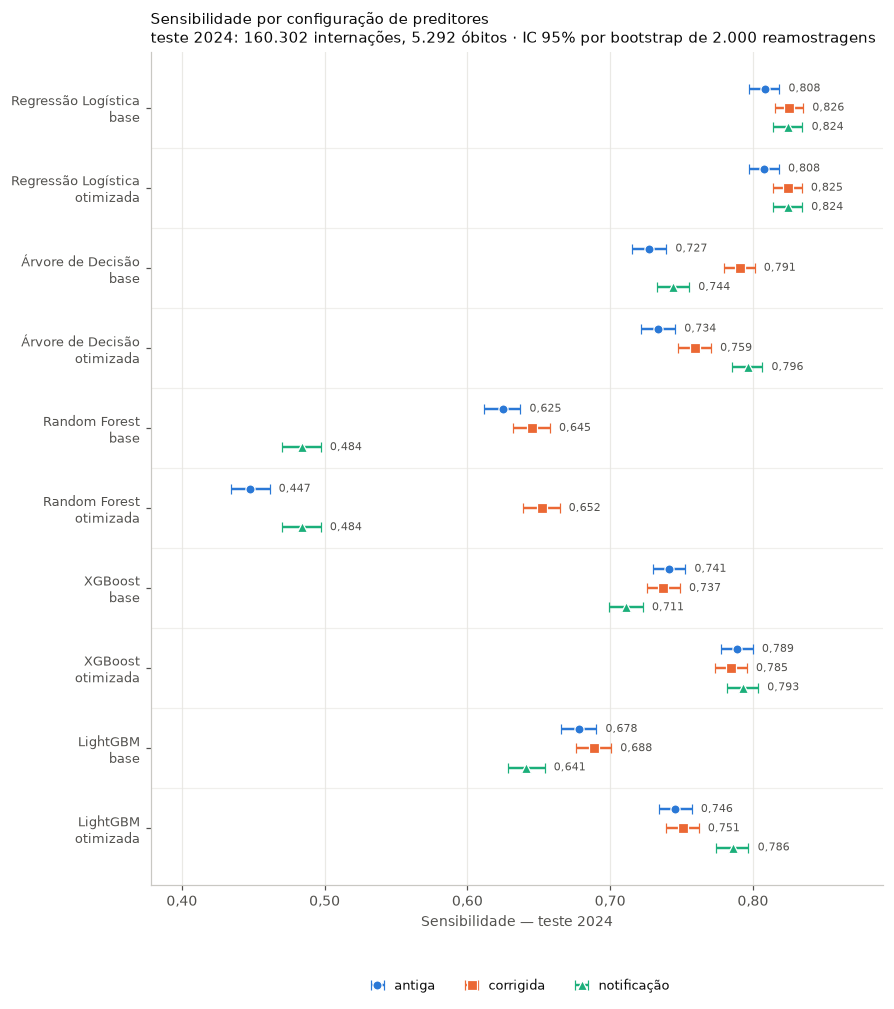

[figura] analysis/plots/retreino/auprc_ic95_por_configuracao.png


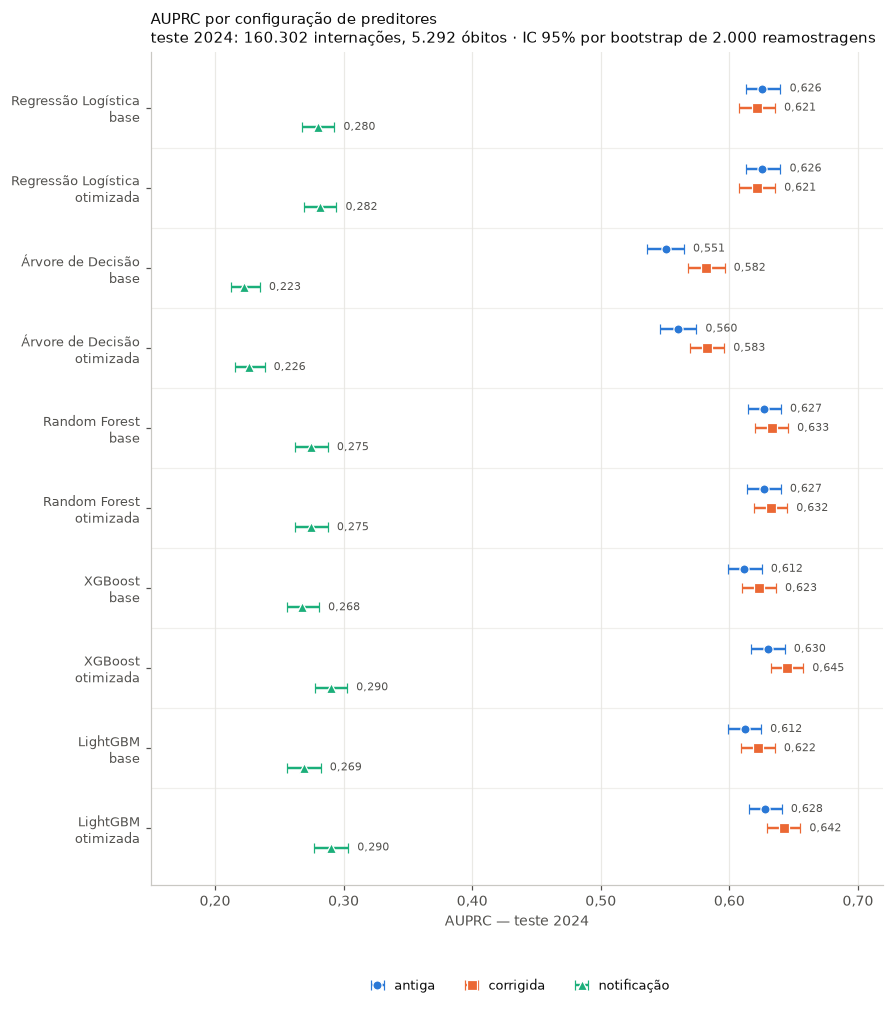

In [16]:
def grafico_floresta(metrica, nome_arquivo):
    rotulos, dados = [], []
    for algo in ALGORITMOS:
        for versao in VERSOES:
            rotulos.append(f'{ALGORITMOS[algo]["rotulo"]}\n{versao}')
            ponto = []
            for cfg in CONFIGS:
                k = chave_de(algo, cfg, versao)
                r = metrica_de[k]
                lo, hi = ic95[(k, metrica)]
                ponto.append((float(r[metrica]), lo, hi))
            dados.append(ponto)

    n = len(rotulos)
    fig, ax = plt.subplots(figsize=(8.2, 0.78 * n + 1.4))
    desloc = [0.24, 0.0, -0.24]

    for j, cfg in enumerate(CONFIGS):
        ys = [n - 1 - i + desloc[j] for i in range(n)]
        est = [d[j][0] for d in dados]
        erro = [[d[j][0] - d[j][1] for d in dados], [d[j][2] - d[j][0] for d in dados]]
        ax.errorbar(est, ys, xerr=erro, fmt=MARCAS[cfg], color=CORES[cfg],
                    ecolor=CORES[cfg], elinewidth=1.6, capsize=3, markersize=6,
                    linestyle='none', markeredgecolor='#ffffff', markeredgewidth=0.8,
                    label=ROTULO_CONFIG[cfg], zorder=3)
        # Rótulo direto à direita do IC: acima da marca ele invadiria a linha de cima.
        for y, d in zip(ys, dados):
            ax.annotate(v_(d[j][0]), (d[j][2], y), textcoords='offset points',
                        xytext=(6, 0), ha='left', va='center', fontsize=7,
                        color='#52514e')

    ax.set_yticks(range(n))
    ax.set_yticklabels(rotulos[::-1], fontsize=8.5)
    ax.set_ylim(-0.7, n - 0.3)
    ax.set_xlabel(f'{ROTULO_METRICA[metrica]} — teste 2024')
    ax.set_title(f'{ROTULO_METRICA[metrica]} por configuração de preditores\n'
                 f'teste 2024: {n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos · '
                 f'IC 95% por bootstrap de {n_(N_BOOTSTRAP)} reamostragens',
                 loc='left', fontsize=10)
    ax.grid(True, axis='x', alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    for y in range(1, n):
        ax.axhline(y - 0.5, color='#f0efec', linewidth=0.8, zorder=0)
    ax.margins(x=0.14)
    ajustar_eixo_x(ax)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09 - 6.0 / (72 * fig.get_figheight())),
              ncol=3, fontsize=8.5, handletextpad=0.3, columnspacing=1.8)
    fig.tight_layout()
    salvar_fig(fig, nome_arquivo)
    plt.show()


grafico_floresta('sensibilidade', 'sensibilidade_ic95_por_configuracao.png')
grafico_floresta('auprc', 'auprc_ic95_por_configuracao.png')

Figura 3 — as seis métricas da versão de maior sensibilidade de cada algoritmo, lado a lado por configuração.

[figura] analysis/plots/retreino/metricas_por_configuracao.png


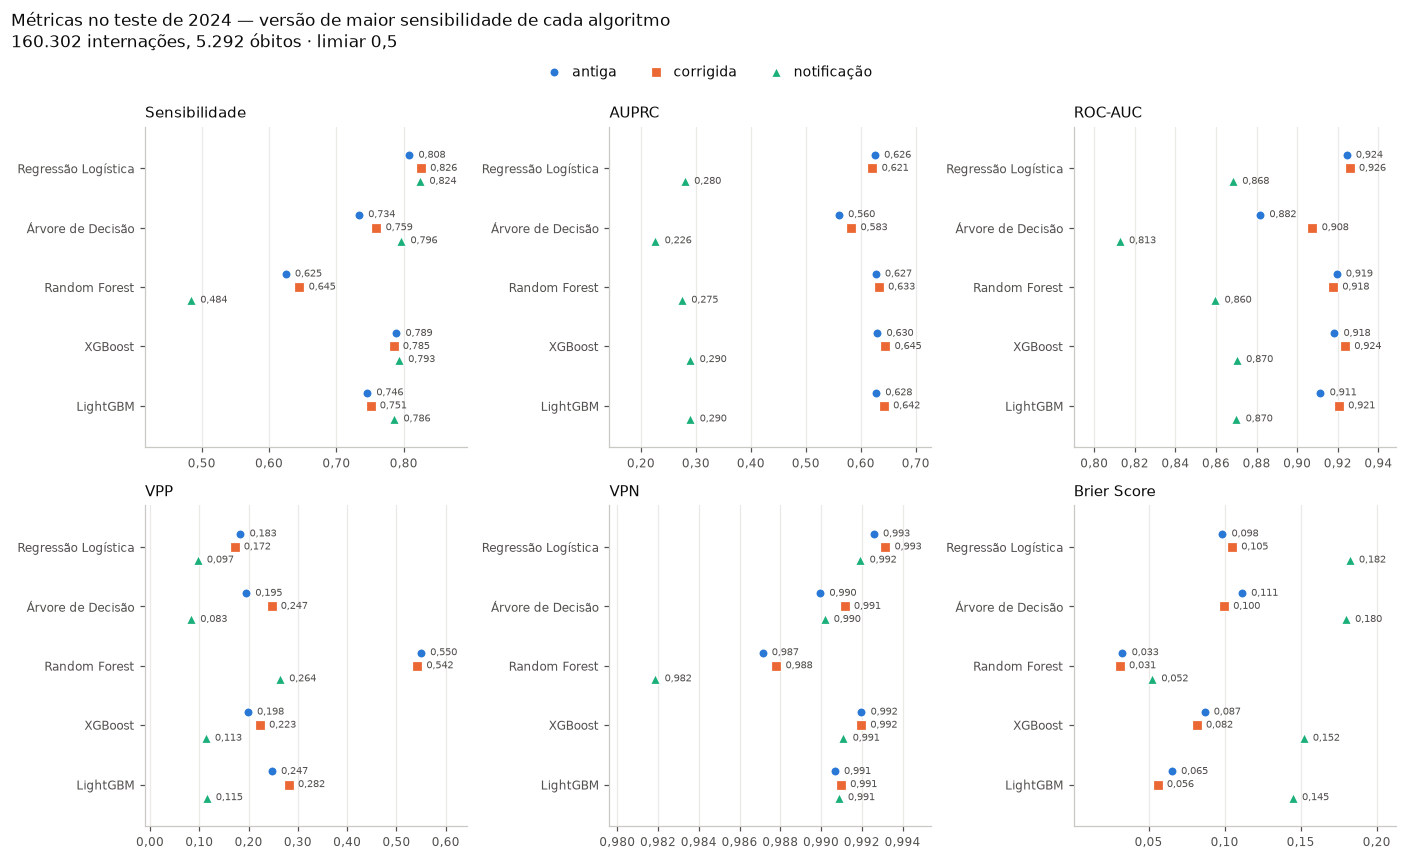

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.8))
algos = list(ALGORITMOS)
n_a = len(algos)

for ax, metrica in zip(axes.ravel(), METRICAS):
    for j, cfg in enumerate(CONFIGS):
        ys, xs = [], []
        for i, algo in enumerate(algos):
            versao = versao_escolhida[algo]
            r = metrica_de[chave_de(algo, cfg, versao)]
            ys.append(n_a - 1 - i + [0.22, 0.0, -0.22][j])
            xs.append(float(r[metrica]))
        ax.plot(xs, ys, MARCAS[cfg], color=CORES[cfg], markersize=6,
                markeredgecolor='#ffffff', markeredgewidth=0.8, linestyle='none',
                label=ROTULO_CONFIG[cfg], zorder=3)
        for y, v in zip(ys, xs):
            ax.annotate(v_(v), (v, y), textcoords='offset points', xytext=(6, 0),
                        ha='left', va='center', fontsize=6.5, color='#52514e')

    ax.set_yticks(range(n_a))
    ax.set_yticklabels([ALGORITMOS[a]['rotulo'] for a in algos][::-1], fontsize=8)
    ax.set_ylim(-0.7, n_a - 0.3)
    ax.set_title(ROTULO_METRICA[metrica], loc='left', fontsize=9.5)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, axis='x', alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.margins(x=0.20)
    ajustar_eixo_x(ax)

fig.tight_layout(rect=(0, 0, 1, 0.90))
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.945), ncol=3,
           fontsize=9, handletextpad=0.3, columnspacing=1.8)
fig.suptitle(f'Métricas no teste de 2024 — versão de maior sensibilidade de cada algoritmo\n'
             f'{n_(N_TESTE)} internações, {n_(EVENTOS_TESTE)} óbitos · limiar {v_(LIMIAR, 1)}',
             x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'metricas_por_configuracao.png')
plt.show()

Figura 4 — curvas precisão-revocação no teste de 2024, um painel por algoritmo.

[figura] analysis/plots/retreino/curvas_precisao_revocacao.png


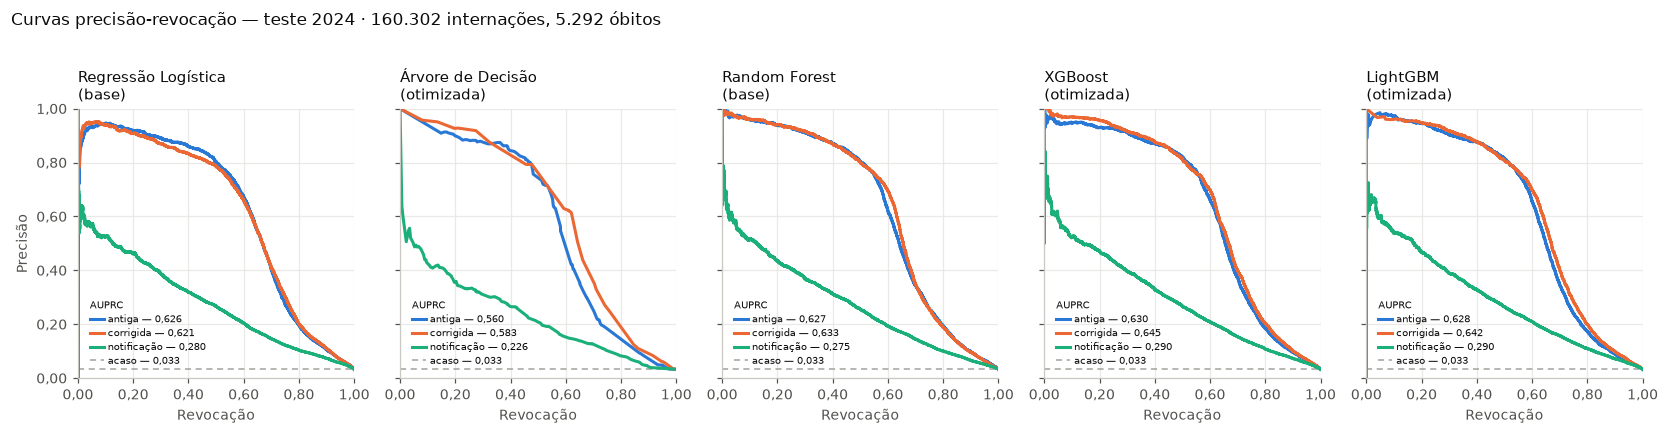

In [18]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, len(ALGORITMOS), figsize=(15.2, 3.9), sharey=True)
prevalencia = EVENTOS_TESTE / N_TESTE

for ax, algo in zip(axes, ALGORITMOS):
    versao = versao_escolhida[algo]
    for cfg in CONFIGS:
        y_true, y_proba = predicoes[chave_de(algo, cfg, versao)]
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        r = metrica_de[chave_de(algo, cfg, versao)]
        ax.plot(rec, prec, color=CORES[cfg], linewidth=2,
                label=f'{ROTULO_CONFIG[cfg]} — {v_(float(r["auprc"]))}')
    # A linha do acaso entra na própria legenda: rotulada sobre o eixo, ela esbarraria
    # ora na legenda, ora nas pontas das curvas.
    ax.axhline(prevalencia, color='#a3a29c', linewidth=1, linestyle=(0, (4, 3)), zorder=1,
               label=f'acaso — {v_(prevalencia)}')
    ax.set_title(f'{ALGORITMOS[algo]["rotulo"]}\n({versao})', loc='left', fontsize=9.5)
    ax.set_xlabel('Revocação')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(eixo_virgula(2))
    ax.yaxis.set_major_formatter(eixo_virgula(2))
    ax.grid(True, alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(loc='lower left', title='AUPRC', fontsize=6.5, title_fontsize=6.5,
              handlelength=1.4, handletextpad=0.4, borderaxespad=0.8,
              labelspacing=0.35, alignment='left')

axes[0].set_ylabel('Precisão')
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.suptitle(f'Curvas precisão-revocação — teste 2024 · {n_(N_TESTE)} internações, '
             f'{n_(EVENTOS_TESTE)} óbitos', x=0.006, y=0.995, ha='left', va='top', fontsize=11)
salvar_fig(fig, 'curvas_precisao_revocacao.png')
plt.show()

## Conclusões

- A configuração antiga não mudou.
  As matrizes de treino e de teste batem com `data/features/baseline/` coluna a coluna e pelo
  sha256 da matriz inteira, com nome, ordem e conteúdo de cada coluna, e 9 das 10 combinações de
  algoritmo e versão reproduzem as probabilidades publicadas com diferença abaixo de 1×10⁻⁶.
  A exceção é a de sempre, a Logistic Regression base, com 2,2×10⁻² de diferença máxima, que não
  move a sensibilidade de 0,8082.

- A correção do `astype(str)` de `treat_data.py` não chega até aqui.
  `dengue_treated_antiga.parquet` não foi regenerado, e nas bases final e sem critérios de gravidade o
  ausente do sexo passou a ser `NaN` de verdade sem mover a matriz de desenho, porque
  `sexo_ausente` testa pertencimento a {F, M} e o codificador ordinal trata as duas formas como
  desconhecido — conferido por sha256 em `notebooks/08`.

- Quatro problemas de codificação foram corrigidos nas configurações final e sem critérios de gravidade.
  A UF de residência saiu do `OrdinalEncoder`, que punha os 27 códigos do IBGE numa escala, e deu
  lugar à macrorregião em one-hot: cinco indicadoras no lugar de vinte e sete, com
  `handle_unknown='error'` e a verificação de cobertura no passo 7 de `treat_data.py`.
  O código 10 da escolaridade saiu da escala ordinal e virou coluna própria.
  O ausente das demográficas deixou de ser imputado e passou a ter coluna declarada:
  `escolaridade_ausente`, `CS_RACA_nan` e `CS_GESTANT_nan` nas cinco famílias, e `sexo_ausente`
  na linear, que exige valor finito.
  E raça/cor, gestação e escolaridade deixaram de chegar ao XGBoost e ao LightGBM como código
  numérico bruto por `remainder='passthrough'`.

- A auditoria por preditor não encontra nenhuma categórica nominal mal codificada fora da linha
  de base.
  As 8 marcações que restam são todas da configuração antiga: UF nas três famílias, escolaridade
  nas três, e raça/cor e gestação nas famílias de reforço.

- A matriz de desenho cresceu mais que a lista de preditores, e passou a diferir entre famílias
  por causa da indicadora de sexo.
  Na antiga são 51 preditores contra 60 colunas nas famílias linear e de árvore e 51 nas de
  reforço.
  Na final são 53 preditores contra 71 colunas na linear e 70 nas outras duas; na sem
  critérios de gravidade, 37 contra 55 e 54.

- O EPP depende de qual das duas contagens se usa.
  Sobre os preditores de entrada é 51,45 na antiga, 49,51 na final e 70,92 na sem critérios de gravidade.
  Sobre as colunas da matriz de desenho cai para 43,73 e 51,45 na antiga, 36,96 na linear
  final e 37,49 nas outras duas famílias, e 47,71 e 48,59 na sem critérios de gravidade, sempre sobre os
  mesmos 127.074 registros e 2.624 óbitos.

- A ordem das configurações por AUPRC se mantém em quatro dos cinco algoritmos: a final acima
  da antiga, e a sem critérios de gravidade muito abaixo das duas.
  A inversão da Logistic Regression persiste, mas encolheu: era -0,0150 e -0,0161 e agora é
  -0,0045 e -0,0044.
  Três mudanças incidem ao mesmo tempo sobre esse modelo nesta rodada — macrorregião no lugar da
  UF, ausente preservado nas demográficas e a indicadora de sexo —, e atribuir o resultado a uma
  delas exigiria uma execução que as separasse, que não é esta.

- Nas outras oito combinações o ganho da final sobre a antiga vai de +0,0052 no Random Forest
  otimizado a +0,0314 na Decision Tree base.
  Só a Decision Tree base separa os intervalos de confiança; nas outras nove combinações os
  IC de antiga e final se sobrepõem.

- A Logistic Regression ganha sensibilidade e ROC-AUC na final ao mesmo tempo em que perde
  AUPRC: sensibilidade de 0,8082 para 0,8256 e ROC-AUC de 0,9243 para 0,9259, com AUPRC de 0,6257
  para 0,6212.
  O VPP acompanha a perda de AUPRC e cai de 0,1832 para 0,1716.

- A Decision Tree base é a que mais se move nas duas métricas: a sensibilidade sai de 0,7271
  [0,7151; 0,7393] na antiga para 0,7908 [0,7796; 0,8012] na final, e o AUPRC de 0,5506
  [0,5361; 0,5646] para 0,5820 [0,5679; 0,5962].

- Retirar os 15 critérios de gravidade continua custando mais da metade do AUPRC nos cinco
  algoritmos: a queda sobre a final vai de 54,7% na Logistic Regression otimizada a 61,7% na
  Decision Tree base, levando o AUPRC de cerca de 0,62 para cerca de 0,28.

- Maior AUPRC do conjunto: XGBoost otimizado na final, 0,6447 [0,6322; 0,6574], com
  sensibilidade 0,7850.
  Maior sensibilidade: Logistic Regression base na final, 0,8256 [0,8151; 0,8352], com VPP
  0,1716.

- O Random Forest da final deixou de empatar com a própria versão base.
  A busca em grade passou a escolher `max_features='log2'`, e não mais os hiperparâmetros da
  base, e as duas versões produzem predições diferentes: 0,6329 de AUPRC na base contra 0,6322 na
  otimizada, no teste de 2024.
  A seleção entre as duas é refeita em `notebooks/10`, pela AUPRC da validação cruzada do treino.

- Os intervalos seguem estreitos: amplitude mediana de 0,0230 na sensibilidade, 0,0259 no AUPRC e
  0,0099 no ROC-AUC, sobre os 5.292 óbitos do teste de 2024.
  O ajuste dos 30 modelos somou 38,4 minutos, com 15,3 deles no Random Forest.
